In [1]:
import os

base_path = "/kaggle/input/the-fake-or-real-dataset"
print("📂 Folders here:", os.listdir(base_path))

📂 Folders here: ['for-norm', 'for-original', 'for-2sec', 'for-rerec']


In [2]:
import os

base_path = "/kaggle/input/the-fake-or-real-dataset/for-2sec/for-2seconds"
print("📁 Subfolders:", os.listdir(base_path))

📁 Subfolders: ['validation', 'training', 'testing']


In [3]:
import librosa
import numpy as np
import os
from tqdm import tqdm

def extract_features(folder_path, label):
    features = []
    labels = []
    for file in tqdm(os.listdir(folder_path), desc=f"Loading {label}"):
        file_path = os.path.join(folder_path, file)
        if file_path.endswith('.wav'):
            try:
                audio, sr = librosa.load(file_path, sr=None)
                mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
                mfccs_mean = np.mean(mfccs.T, axis=0)
                features.append(mfccs_mean)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {file}: {e}")
    return np.array(features), np.array(labels)

base_path = "/kaggle/input/the-fake-or-real-dataset/for-2sec/for-2seconds"

train_real_path = os.path.join(base_path, "training/real")
train_fake_path = os.path.join(base_path, "training/fake")

val_real_path = os.path.join(base_path, "validation/real")
val_fake_path = os.path.join(base_path, "validation/fake")

test_real_path = os.path.join(base_path, "testing/real")
test_fake_path = os.path.join(base_path, "testing/fake")

# Extract features for each split
X_train_real, y_train_real = extract_features(train_real_path, 1)
X_train_fake, y_train_fake = extract_features(train_fake_path, 0)

X_val_real, y_val_real = extract_features(val_real_path, 1)
X_val_fake, y_val_fake = extract_features(val_fake_path, 0)

X_test_real, y_test_real = extract_features(test_real_path, 1)
X_test_fake, y_test_fake = extract_features(test_fake_path, 0)

# Combine
X_train = np.concatenate((X_train_real, X_train_fake))
y_train = np.concatenate((y_train_real, y_train_fake))

X_val = np.concatenate((X_val_real, X_val_fake))
y_val = np.concatenate((y_val_real, y_val_fake))

X_test = np.concatenate((X_test_real, X_test_fake))
y_test = np.concatenate((y_test_real, y_test_fake))

print(f"✅ Training: {X_train.shape}, Validation: {X_val.shape}, Testing: {X_test.shape}")

Loading 0: 100%|██████████| 544/544 [00:13<00:00, 40.92it/s]

✅ Training: (13956, 40), Validation: (2826, 40), Testing: (1088, 40)


In [4]:
# Print dataset summary
train_real_count = len(y_train_real)
train_fake_count = len(y_train_fake)
val_real_count = len(y_val_real)
val_fake_count = len(y_val_fake)
test_real_count = len(y_test_real)
test_fake_count = len(y_test_fake)

print(f"Training set → Real: {train_real_count} Fake: {train_fake_count}")
print(f"Validation set → Real: {val_real_count} Fake: {val_fake_count}")
print(f"Testing set → Real: {test_real_count} Fake: {test_fake_count}")

Training set → Real: 6978 Fake: 6978
Validation set → Real: 1413 Fake: 1413
Testing set → Real: 544 Fake: 544


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(40, 87, 1)),  # MFCC shape (n_mfcc, time, 1)
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

2025-10-09 04:16:22.024238: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759983382.265111      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759983382.337982      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-09 04:16:36.837339: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 85, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 20, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 20, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,310,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,793 (5.07 MB)

 Trainable params: 1,329,793 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import librosa, numpy as np, os
from tqdm import tqdm

# ✅ Corrected base paths
base_path = "/kaggle/input/the-fake-or-real-dataset/for-2sec/for-2seconds"
train_real = os.path.join(base_path, "training/real")
train_fake = os.path.join(base_path, "training/fake")
val_real = os.path.join(base_path, "validation/real")
val_fake = os.path.join(base_path, "validation/fake")

# Feature extraction function
def extract_features(file_path, max_pad_len=87):
    try:
        audio, sr = librosa.load(file_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]
        return mfcc
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# --- Load and label data ---
X_train, y_train, X_val, y_val = [], [], [], []

print("🎧 Extracting training data...")
for folder, label in [(train_real, 0), (train_fake, 1)]:
    for f in tqdm(os.listdir(folder)):
        path = os.path.join(folder, f)
        feat = extract_features(path)
        if feat is not None:
            X_train.append(feat)
            y_train.append(label)

print("🎧 Extracting validation data...")
for folder, label in [(val_real, 0), (val_fake, 1)]:
    for f in tqdm(os.listdir(folder)):
        path = os.path.join(folder, f)
        feat = extract_features(path)
        if feat is not None:
            X_val.append(feat)
            y_val.append(label)

# Convert to arrays
X_train = np.array(X_train)[..., np.newaxis]
X_val = np.array(X_val)[..., np.newaxis]
y_train = np.array(y_train)
y_val = np.array(y_val)

print(f"✅ Training samples: {len(X_train)} | Validation samples: {len(X_val)}")

# --- Train the CNN ---
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

🎧 Extracting training data...


100%|██████████| 6978/6978 [01:00<00:00, 115.09it/s]


🎧 Extracting validation data...


100%|██████████| 1413/1413 [00:12<00:00, 116.10it/s]


✅ Training samples: 13956 | Validation samples: 2826
Epoch 1/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.6670 - loss: 1.6053 - val_accuracy: 0.9076 - val_loss: 0.2094
Epoch 2/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 30s 69ms/step - accuracy: 0.9106 - loss: 0.2312 - val_accuracy: 0.9582 - val_loss: 0.1205
Epoch 3/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.9498 - loss: 0.1449 - val_accuracy: 0.9590 - val_loss: 0.1065
Epoch 4/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.9427 - loss: 0.1514 - val_accuracy: 0.9742 - val_loss: 0.0705
Epoch 5/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.9650 - loss: 0.1056 - val_accuracy: 0.9685 - val_loss: 0.0813
Epoch 6/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.9660 - loss: 0.0939 - val_accuracy: 0.9791 - val_loss: 0.0633
Epoch 7/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.9740 - loss: 0.0795 - val_accuracy: 0.9770 - val_loss: 0.0891
Epoch 8/20
437/437 ━━━━━━━━━━━━━━━━━━


🎤 Extracting test data features...


100%|██████████| 544/544 [00:04<00:00, 113.50it/s]



✅ Test data shape: (1088, 40, 87, 1), Labels: (1088,)
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9437 - loss: 0.1698

🎯 Test Accuracy: 95.50%
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

📊 Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.94      0.95       544
        Fake       0.94      0.97      0.96       544

    accuracy                           0.95      1088
   macro avg       0.96      0.95      0.95      1088
weighted avg       0.96      0.95      0.95      1088



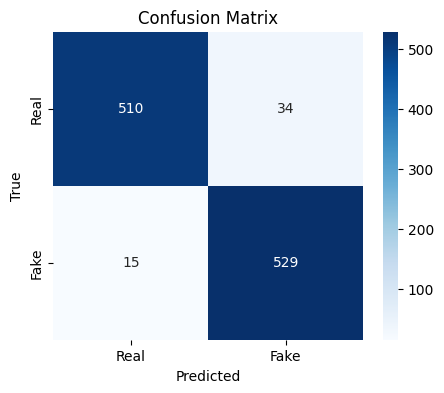

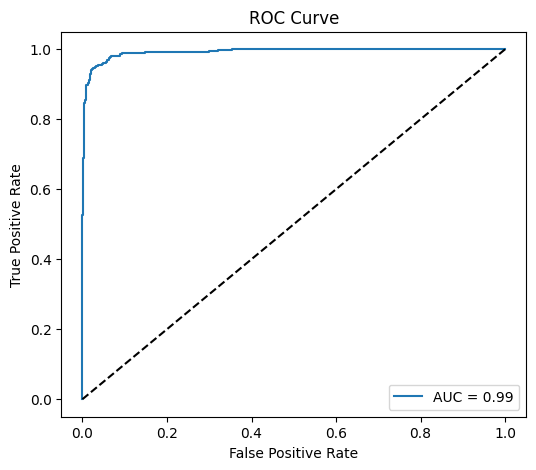

In [7]:
# STEP 5 — Evaluate the trained model on test data

import numpy as np
import librosa
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- Define test paths ---
test_real = os.path.join(base_path, "testing", "real")
test_fake = os.path.join(base_path, "testing", "fake")

print("\n🎤 Extracting test data features...")

X_test, y_test = [], []
for folder, label in [(test_real, 0), (test_fake, 1)]:
    for f in tqdm(os.listdir(folder)):
        try:
            file_path = os.path.join(folder, f)
            y, sr = librosa.load(file_path, sr=16000)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
            if mfcc.shape[1] < 87:
                mfcc = np.pad(mfcc, ((0,0), (0,87 - mfcc.shape[1])), mode='constant')
            elif mfcc.shape[1] > 87:
                mfcc = mfcc[:, :87]
            X_test.append(mfcc)
            y_test.append(label)
        except Exception:
            continue

X_test = np.array(X_test)
y_test = np.array(y_test)

# Reshape for CNN input
X_test = X_test[..., np.newaxis]

print(f"\n✅ Test data shape: {X_test.shape}, Labels: {y_test.shape}")

# --- Evaluate the model ---
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\n🎯 Test Accuracy: {test_acc*100:.2f}%")

# --- Generate predictions ---
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# --- Classification report ---
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Real","Fake"], yticklabels=["Real","Fake"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [14]:
import os
user_audio_path = "/kaggle/input/testing-input"
audio_files = [f for f in os.listdir(user_audio_path) if f.lower().endswith(('.wav','.m4a','.flac','.mp3'))]
print("Found files:", audio_files)

Found files: ['fake_2.mp3', 'real_1.m4a', 'fake_1.mp3', 'real_2.m4a']


In [15]:
import librosa
import numpy as np

def extract_mfcc_for_model(file_path, sr=16000, n_mfcc=40, max_len=87):
    """
    Returns MFCC shaped (40, max_len) as float32, padded/truncated to max_len.
    """
    y, _ = librosa.load(file_path, sr=sr)            # resample to 16 kHz (same as training)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, pad_width=((0,0),(0, max_len - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc.astype(np.float32)

In [16]:
for f in audio_files:
    p = os.path.join(user_audio_path, f)
    mf = extract_mfcc_for_model(p)
    print(f, "->", mf.shape)

fake_2.mp3 -> (40, 87)


/tmp/ipykernel_38/2489301196.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(file_path, sr=sr)            # resample to 16 kHz (same as training)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


real_1.m4a -> (40, 87)
fake_1.mp3 -> (40, 87)
real_2.m4a -> (40, 87)


/tmp/ipykernel_38/2489301196.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(file_path, sr=sr)            # resample to 16 kHz (same as training)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [17]:
for f in audio_files:
    p = os.path.join(user_audio_path, f)
    mf = extract_mfcc_for_model(p)              # (40,87)
    x = mf[np.newaxis, ..., np.newaxis]         # shape -> (1,40,87,1)
    pred = model.predict(x, verbose=0)[0][0]    # sigmoid output: ~0..1
    label = "🔴 FAKE" if pred > 0.5 else "🟢 REAL"
    confidence = pred if pred > 0.5 else (1 - pred)
    print(f"{f}  => {label}  (prob={pred:.4f}, confidence={confidence:.2f})")

fake_2.mp3  => 🔴 FAKE  (prob=1.0000, confidence=1.00)


/tmp/ipykernel_38/2489301196.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(file_path, sr=sr)            # resample to 16 kHz (same as training)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


real_1.m4a  => 🟢 REAL  (prob=0.0002, confidence=1.00)
fake_1.mp3  => 🔴 FAKE  (prob=0.9885, confidence=0.99)


/tmp/ipykernel_38/2489301196.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(file_path, sr=sr)            # resample to 16 kHz (same as training)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


real_2.m4a  => 🟢 REAL  (prob=0.0000, confidence=1.00)


In [19]:
model.save("/kaggle/working/fake_voice_model.h5")
print("✅ Model saved successfully at /kaggle/working/fake_voice_model.h5")

✅ Model saved successfully at /kaggle/working/fake_voice_model.h5


In [20]:
%%writefile app.py
import streamlit as st
import numpy as np
import librosa
from tensorflow.keras.models import load_model

# Load your trained model
model = load_model("fake_voice_model.h5")

# Streamlit UI
st.title("🎙️ Real vs Fake Voice Detector")
st.write("Upload an audio file to check if it's **real or fake**.")

# Upload audio file
uploaded_file = st.file_uploader("Choose an audio file", type=["wav", "mp3", "flac", "m4a"])

# Feature extraction
def extract_mfcc_for_model(file, sr=16000, n_mfcc=40, max_len=87):
    y, _ = librosa.load(file, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, max_len - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc.astype(np.float32)

# Predict button
if uploaded_file is not None:
    st.audio(uploaded_file, format="audio/wav")
    mf = extract_mfcc_for_model(uploaded_file)
    x = mf[np.newaxis, ..., np.newaxis]
    pred = model.predict(x, verbose=0)[0][0]

    label = "🟢 REAL" if pred < 0.5 else "🔴 FAKE"
    confidence = (1 - pred) if pred < 0.5 else pred

    st.subheader(f"Prediction: {label}")
    st.write(f"**Confidence:** {confidence:.2f}")

Writing app.py
